# RQ1: Comparing the LLM-based approaches

Comparing **3 approaches** (SF, AST, RAG) across **8 models × 18 files = 144 blocks**.

Each (model, file) pair is treated as a single dataset/block.

| Item | Value |
|------|-------|
| Datasets (blocks) | 144 |
| Algorithms | Source File, AST, RAG |
| Global test | Friedman |
| Concordance | Kendall's W |
| Post-hoc | Nemenyi |
| Visualization | Critical Distance (CD) diagram |

Running the notebook requires the following packages: `numpy`, `pandas`, `matplotlib`, `scipy`, `ipython`, `scikit_posthocs`, `autorank`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

In [2]:
files = [
    "parser.ts", "checker.ts", "emitter.ts", "binder.ts",
    "services.ts", "completions.ts", "session.ts",
    "uri.ts", "instantiationService.ts", "editorService.ts",
    "editorBrowser.ts", "workbench.ts",
    "parse.ts", "compileScript.ts", "src/render.ts",
    "init.ts", "instance/render.ts", "patch.ts",
]

models = [
    "Qwen 3 (30B)", "Qwen 3 Coder (30B)", "Qwen 2.5 Coder (32B)",
    "DeepSeek-R1 (32B)", "StarCoder 2 (15B)",
    "GPT-3.5-turbo", "GPT-4", "GPT-5 mini",
]

# (SF, AST, RAG) per file, in file order
raw = {
    "Qwen 3 (30B)": [
        (0.05, 0.02, 0.10), (0.12, 0.00, 0.26), (0.45, 0.45, 0.43),
        (0.27, 0.34, 0.34), (0.00, 0.00, 0.12), (0.10, 0.00, 0.05),
        (0.06, 0.15, 0.28),
        (0.16, 0.02, 0.25), (0.18, 0.07, 0.14), (0.00, 0.02, 0.18),
        (0.50, 0.35, 0.22), (0.12, 0.23, 0.58),
        (0.25, 0.16, 0.37), (0.10, 0.00, 0.18), (0.06, 0.08, 0.08),
        (0.66, 0.14, 0.53), (0.15, 0.15, 0.25), (0.00, 0.05, 0.00),
    ],
    "Qwen 3 Coder (30B)": [
        (0.15, 0.07, 0.37), (0.16, 0.04, 0.22), (0.45, 0.32, 0.56),
        (0.36, 0.43, 0.34), (0.04, 0.10, 0.08), (0.18, 0.05, 0.05),
        (0.02, 0.26, 0.54),
        (0.25, 0.22, 0.36), (0.11, 0.17, 0.13), (0.10, 0.00, 0.22),
        (0.30, 0.11, 0.30), (0.12, 0.38, 0.74),
        (0.20, 0.12, 0.53), (0.14, 0.18, 0.18), (0.06, 0.00, 0.03),
        (0.54, 0.05, 0.52), (0.23, 0.20, 0.38), (0.00, 0.05, 0.13),
    ],
    "Qwen 2.5 Coder (32B)": [
        (0.00, 0.00, 0.00), (0.10, 0.31, 0.29), (0.28, 0.42, 0.50),
        (0.27, 0.27, 0.21), (0.00, 0.04, 0.10), (0.08, 0.02, 0.03),
        (0.00, 0.18, 0.43),
        (0.23, 0.26, 0.26), (0.12, 0.00, 0.10), (0.00, 0.08, 0.16),
        (0.26, 0.21, 0.28), (0.09, 0.13, 0.21),
        (0.28, 0.31, 0.26), (0.09, 0.00, 0.13), (0.07, 0.00, 0.07),
        (0.25, 0.08, 0.34), (0.16, 0.23, 0.23), (0.00, 0.00, 0.00),
    ],
    "DeepSeek-R1 (32B)": [
        (0.00, 0.00, 0.00), (0.02, 0.00, 0.17), (0.22, 0.07, 0.22),
        (0.13, 0.11, 0.16), (0.00, 0.00, 0.05), (0.00, 0.00, 0.00),
        (0.00, 0.08, 0.21),
        (0.02, 0.00, 0.03), (0.04, 0.05, 0.06), (0.10, 0.00, 0.00),
        (0.16, 0.23, 0.23), (0.04, 0.06, 0.13),
        (0.24, 0.06, 0.27), (0.00, 0.00, 0.08), (0.03, 0.00, 0.04),
        (0.26, 0.21, 0.37), (0.18, 0.03, 0.14), (0.00, 0.00, 0.00),
    ],
    "StarCoder 2 (15B)": [
        (0.02, 0.02, 0.05), (0.00, 0.00, 0.14), (0.34, 0.21, 0.25),
        (0.11, 0.18, 0.14), (0.00, 0.00, 0.00), (0.00, 0.00, 0.00),
        (0.02, 0.00, 0.25),
        (0.14, 0.10, 0.21), (0.06, 0.00, 0.11), (0.00, 0.00, 0.01),
        (0.15, 0.18, 0.20), (0.14, 0.18, 0.27),
        (0.31, 0.15, 0.27), (0.00, 0.05, 0.06), (0.01, 0.01, 0.00),
        (0.15, 0.06, 0.32), (0.23, 0.10, 0.28), (0.00, 0.00, 0.00),
    ],
    "GPT-3.5-turbo": [
        (0.02, 0.00, 0.00), (0.18, 0.23, 0.21), (0.47, 0.36, 0.56),
        (0.30, 0.28, 0.31), (0.00, 0.00, 0.23), (0.01, 0.00, 0.01),
        (0.00, 0.04, 0.20),
        (0.22, 0.14, 0.25), (0.14, 0.00, 0.12), (0.00, 0.00, 0.08),
        (0.23, 0.17, 0.27), (0.05, 0.03, 0.11),
        (0.26, 0.26, 0.23), (0.06, 0.00, 0.18), (0.01, 0.00, 0.03),
        (0.24, 0.00, 0.19), (0.19, 0.19, 0.28), (0.00, 0.00, 0.01),
    ],
    "GPT-4": [
        (0.04, 0.06, 0.06), (0.11, 0.03, 0.22), (0.54, 0.52, 0.67),
        (0.22, 0.26, 0.27), (0.00, 0.01, 0.08), (0.08, 0.00, 0.08),
        (0.04, 0.00, 0.25),
        (0.14, 0.04, 0.23), (0.15, 0.05, 0.13), (0.00, 0.00, 0.26),
        (0.47, 0.23, 0.54), (0.00, 0.01, 0.15),
        (0.17, 0.04, 0.17), (0.03, 0.00, 0.24), (0.02, 0.07, 0.07),
        (0.35, 0.16, 0.38), (0.14, 0.15, 0.19), (0.00, 0.00, 0.00),
    ],
    "GPT-5 mini": [
        (0.12, 0.03, 0.21), (0.19, 0.01, 0.23), (0.47, 0.44, 0.58),
        (0.32, 0.29, 0.38), (0.03, 0.05, 0.05), (0.14, 0.11, 0.26),
        (0.07, 0.05, 0.29),
        (0.21, 0.13, 0.21), (0.15, 0.16, 0.15), (0.16, 0.04, 0.27),
        (0.27, 0.16, 0.38), (0.38, 0.25, 0.58),
        (0.15, 0.07, 0.23), (0.15, 0.17, 0.21), (0.03, 0.00, 0.07),
        (0.35, 0.10, 0.49), (0.16, 0.13, 0.15), (0.02, 0.00, 0.05),
    ],
}

# Build DataFrame: each row = one (model, file) block
records = []
for model in models:
    for i, f in enumerate(files):
        sf, ast_val, rag = raw[model][i]
        records.append({"model": model, "file": f, "SF": sf, "AST": ast_val, "RAG": rag})

df_full = pd.DataFrame(records)
df_bench = df_full[["SF", "AST", "RAG"]].copy()

print(f"Shape: {df_bench.shape}  (expected 144 x 3)")
assert df_bench.shape == (144, 3), "Unexpected shape"
df_full.head(10)

Shape: (144, 3)  (expected 144 x 3)


,model,file,SF,AST,RAG
0,Qwen 3 (30B),parser.ts,0.05,0.02,0.10
1,Qwen 3 (30B),checker.ts,0.12,0.00,0.26
2,Qwen 3 (30B),emitter.ts,0.45,0.45,0.43
3,Qwen 3 (30B),binder.ts,0.27,0.34,0.34
4,Qwen 3 (30B),services.ts,0.00,0.00,0.12
5,Qwen 3 (30B),completions.ts,0.10,0.00,0.05
6,Qwen 3 (30B),session.ts,0.06,0.15,0.28
7,Qwen 3 (30B),uri.ts,0.16,0.02,0.25
8,Qwen 3 (30B),instantiationService.ts,0.18,0.07,0.14
9,Qwen 3 (30B),editorService.ts,0.00,0.02,0.18


## Descriptive statistics per approach

In [3]:
df_bench.describe().round(4)

,SF,AST,RAG
count,144.0000,144.0000,144.0000
mean,0.1409,0.1054,0.2112
std,0.1391,0.1197,0.1605
min,0.0000,0.0000,0.0000
25%,0.0200,0.0000,0.0800
50%,0.1200,0.0600,0.2100
75%,0.2200,0.1725,0.2725
max,0.6600,0.5200,0.7400


## Friedman test

Non-parametric repeated-measures test: are there significant differences among SF, AST, RAG across the 144 blocks?

In [4]:
fried = stats.friedmanchisquare(df_bench["SF"], df_bench["AST"], df_bench["RAG"])
print(f"Friedman test: chi2 = {fried.statistic:.4f},  p = {fried.pvalue:.6f}")

if fried.pvalue < 0.05:
    print("→ Significant at α = 0.05: at least one approach differs.")
else:
    print("→ Not significant at α = 0.05.")

Friedman test: chi2 = 97.4831,  p = 0.000000
→ Significant at α = 0.05: at least one approach differs.


## Kendall's W

Kendall's W measures the degree of agreement among the 18 files in how they rank the 3 approaches. W = 0 means no agreement; W = 1 means perfect agreement.

In [5]:
# Kendall's W (concordance) for the 3-approach analysis
# W = chi2 / (n * (k - 1))
n_blocks = len(df_bench)
k_algo = len(df_bench.columns)
W_3 = fried.statistic / (n_blocks * (k_algo - 1))
print(f"Kendall's W = {W_3:.4f}  (n={n_blocks}, k={k_algo})")

if W_3 < 0.3:
    interp = "weak"
elif W_3 < 0.5:
    interp = "moderate"
elif W_3 < 0.7:
    interp = "substantial"
else:
    interp = "strong"
print(f"Interpretation: {interp} concordance among blocks")

Kendall's W = 0.3385  (n=144, k=3)
Interpretation: moderate concordance among blocks


In [6]:
# Ensure post-hoc + CD-diagram libraries are available
try:
    import scikit_posthocs as sp
    from autorank import autorank, plot_stats
except ImportError:
    !pip -q install scikit-posthocs autorank
    import scikit_posthocs as sp
    from autorank import autorank, plot_stats

## Nemenyi post-hoc test

Pairwise comparison of all approaches after a significant Friedman result.

In [7]:
nemenyi = sp.posthoc_nemenyi_friedman(df_bench.values)
nemenyi.index = df_bench.columns
nemenyi.columns = df_bench.columns
print("Nemenyi p-value matrix:")
display(nemenyi)

Nemenyi p-value matrix:


,SF,AST,RAG
SF,1.000000e+00,0.02007,8.642088e-10
AST,2.007013e-02,1.00000,0.000000e+00
RAG,8.642088e-10,0.00000,1.000000e+00


## Plots: boxplot, average ranks, CD diagram

/var/folders/92/y99771cx43s7v0wjq5d8j2vw0000gn/T/ipykernel_94969/2833895069.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


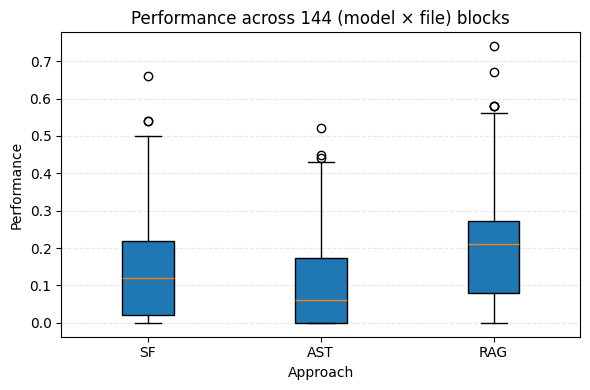

In [8]:
# Boxplot of the three approaches across all 144 blocks
plt.figure(figsize=(6, 4))
plt.boxplot(
    [df_bench[c] for c in df_bench.columns],
    labels=list(df_bench.columns),
    patch_artist=True,
)
plt.title("Performance across 144 (model × file) blocks")
plt.xlabel("Approach")
plt.ylabel("Performance")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Average ranks (lower is better):


,avg_rank
RAG,1.399306
SF,2.142361
AST,2.458333


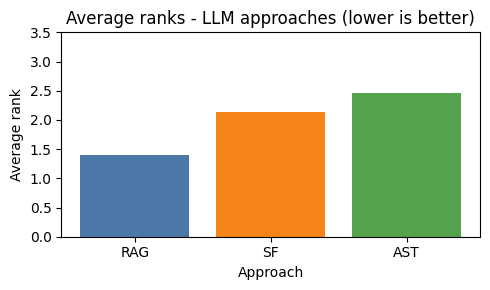

In [9]:
# Average ranks (Demšar-style; rank 1 = best, higher value → lower rank)
ranks = df_bench.rank(axis=1, ascending=False)   # higher value → rank 1
avg_ranks = ranks.mean(axis=0).sort_values()
print("Average ranks (lower is better):")
display(avg_ranks.to_frame("avg_rank"))

plt.figure(figsize=(5, 3))
plt.bar(avg_ranks.index, avg_ranks.values, color=['#4C78A8','#F58518','#54A24B'])
plt.title("Average ranks - LLM approaches (lower is better)")
plt.xlabel("Approach")
plt.ylabel("Average rank")
plt.ylim(0, 3.5)
plt.tight_layout()
plt.show()

Rejecting null hypothesis that data is normal for column SF (p=0.000000<0.016667)
Rejecting null hypothesis that data is normal for column AST (p=0.000000<0.016667)
Rejecting null hypothesis that data is normal for column RAG (p=0.000001<0.016667)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.019382<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences are significant,if the distance between the mean ranks is greater than the critical distance.
     meanrank  median   mad ci_lower ci_upper effect_size   magnitude  \
AST  2.458333    0.06  0.06     0.03     0.13         0.0  negligible   
SF   2.142361    0.12   0.1     0.06     0.16   -0.490764       small   
RAG  1.399306    0.21   0.1     0.14     0.25    -1.22691       large   

    effect_size_above magnitude_above  
AST               0.

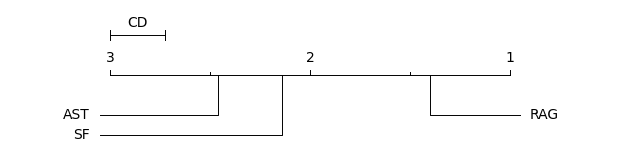

Omnibus test : friedman  (p = 0.000000)
Post-hoc test: nemenyi
Critical Difference (CD): 0.2762

Rank summary (lower rank = better):


,meanrank,median,mad,ci_lower,ci_upper,effect_size,magnitude,effect_size_above,magnitude_above
AST,2.4583,0.06,0.06,0.03,0.13,0.0,negligible,0.0,negligible
SF,2.1424,0.12,0.1,0.06,0.16,-0.490764,small,-0.490764,small
RAG,1.3993,0.21,0.1,0.14,0.25,-1.22691,large,-0.607042,medium


In [10]:
# Critical Distance diagram via autorank
# order='descending' because higher performance values are better
result = autorank(df_bench, alpha=0.05, verbose=True, order="descending")

plot_stats(result)
plt.show()

# ── Clean summary of the autorank result ──
print(f"Omnibus test : {result.omnibus}  (p = {result.pvalue:.6f})")
print(f"Post-hoc test: {result.posthoc}")
print(f"Critical Difference (CD): {result.cd:.4f}")
print()
print("Rank summary (lower rank = better):")
display(result.rankdf.round(4))

-----

# RQ3: Comparing LLM-based approaches to SynTest's Proportional Sampling

Comparing **4 approaches** (Source File, AST, RAG, Proportional Sampling) across **18 files** for a single model (Qwen 3 Coder 30B).

| Item | Value |
|------|-------|
| Datasets (blocks) | 18 files |
| Algorithms | Source File, AST, RAG, Proportional Sampling |
| Global test | Friedman & ANOVA |
| Concordance | Kendall's W |
| Post-hoc | Nemenyi & Tukey's HSD |
| Visualization | Error bar plot |


In [11]:
data_4 = {
    "file": [
        "parser.ts", "checker.ts", "emitter.ts", "binder.ts",
        "services.ts", "completions.ts", "session.ts",
        "uri.ts", "instantiationService.ts", "editorService.ts",
        "editorBrowser.ts", "workbench.ts",
        "parse.ts", "compileScript.ts", "src/render.ts",
        "init.ts", "instance/render.ts", "patch.ts",
    ],
    "Source File": [
        0.15, 0.16, 0.45, 0.36, 0.04, 0.18, 0.02,
        0.25, 0.11, 0.10, 0.30, 0.12,
        0.20, 0.14, 0.06, 0.54, 0.23, 0.00,
    ],
    "AST": [
        0.07, 0.04, 0.32, 0.43, 0.10, 0.05, 0.26,
        0.22, 0.17, 0.00, 0.11, 0.38,
        0.12, 0.18, 0.00, 0.05, 0.20, 0.00,
    ],
    "RAG": [
        0.37, 0.22, 0.56, 0.34, 0.08, 0.05, 0.54,
        0.36, 0.13, 0.22, 0.30, 0.74,
        0.53, 0.18, 0.03, 0.52, 0.38, 0.13,
    ],
    "Prop. Sampling": [
        0.03, 0.28, 0.49, 0.15, 0.00, 0.10, 0.17,
        0.43, 0.36, 0.00, 0.21, 0.24,
        0.06, 0.15, 0.06, 0.48, 0.26, 0.07,
    ],
}

df_4full = pd.DataFrame(data_4)
df_4 = df_4full[["Source File", "AST", "RAG", "Prop. Sampling"]].copy()

print(f"Shape: {df_4.shape}  (expected 18 × 4)")
assert df_4.shape == (18, 4)
df_4full

Shape: (18, 4)  (expected 18 × 4)


,file,Source File,AST,RAG,Prop. Sampling
0,parser.ts,0.15,0.07,0.37,0.03
1,checker.ts,0.16,0.04,0.22,0.28
2,emitter.ts,0.45,0.32,0.56,0.49
3,binder.ts,0.36,0.43,0.34,0.15
4,services.ts,0.04,0.10,0.08,0.00
5,completions.ts,0.18,0.05,0.05,0.10
6,session.ts,0.02,0.26,0.54,0.17
7,uri.ts,0.25,0.22,0.36,0.43
8,instantiationService.ts,0.11,0.17,0.13,0.36
9,editorService.ts,0.10,0.00,0.22,0.00


## Friedman test

Non-parametric repeated-measures test: are there significant differences among SF, AST, RAG, Proportional Sampling across the 18 blocks?

In [12]:
fried_4 = stats.friedmanchisquare(
    df_4["Source File"], df_4["AST"], df_4["RAG"], df_4["Prop. Sampling"]
)
print(f"Friedman test: chi2 = {fried_4.statistic:.4f},  p = {fried_4.pvalue:.6f}")

if fried_4.pvalue < 0.05:
    print("→ Significant at α = 0.05: at least one approach differs.")
else:
    print("→ Not significant at α = 0.05.")

Friedman test: chi2 = 9.4310,  p = 0.024076
→ Significant at α = 0.05: at least one approach differs.


## Kendall's W

Kendall's W measures the degree of agreement among the 18 files in how they rank the 4 approaches. W = 0 means no agreement; W = 1 means perfect agreement.

In [13]:
# Kendall's W from the Friedman chi-square:
#   W = chi2 / (n * (k - 1))
# where n = number of blocks (files), k = number of approaches
n_files = len(df_4)
k_approaches = len(df_4.columns)
W_4 = fried_4.statistic / (n_files * (k_approaches - 1))
print(f"Kendall's W = {W_4:.4f}  (n={n_files}, k={k_approaches})")

if W_4 < 0.3:
    interp = "weak"
elif W_4 < 0.5:
    interp = "moderate"
elif W_4 < 0.7:
    interp = "substantial"
else:
    interp = "strong"
print(f"Interpretation: {interp} concordance among files")

Kendall's W = 0.1746  (n=18, k=4)
Interpretation: weak concordance among files


## Nemenyi post-hoc test

In [14]:
nemenyi_4 = sp.posthoc_nemenyi_friedman(df_4.values)
nemenyi_4.index = df_4.columns
nemenyi_4.columns = df_4.columns
print("Nemenyi p-value matrix:")
display(nemenyi_4)

Nemenyi p-value matrix:


,Source File,AST,RAG,Prop. Sampling
Source File,1.000000,0.835794,0.164467,0.999904
AST,0.835794,1.000000,0.019255,0.802874
RAG,0.164467,0.019255,1.000000,0.187522
Prop. Sampling,0.999904,0.802874,0.187522,1.000000


## Plots: boxplot, average ranks, CI diagram

/var/folders/92/y99771cx43s7v0wjq5d8j2vw0000gn/T/ipykernel_94969/3530305227.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


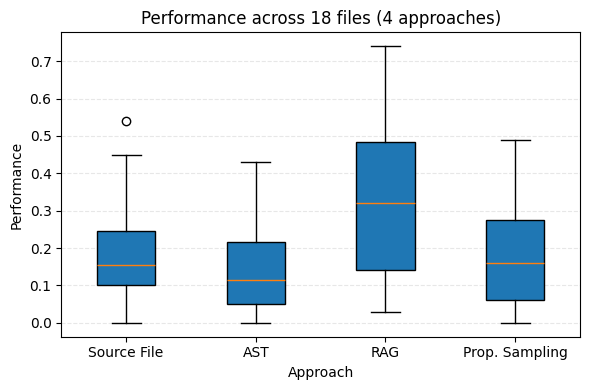

In [15]:
# Boxplot of the three approaches across all 144 blocks
plt.figure(figsize=(6, 4))
plt.boxplot(
    [df_4[c] for c in df_4.columns],
    labels=list(df_4.columns),
    patch_artist=True,
)
plt.title("Performance across 18 files (4 approaches)")
plt.xlabel("Approach")
plt.ylabel("Performance")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Average ranks (lower is better):


,avg_rank
RAG,1.750000
Prop. Sampling,2.611111
Source File,2.638889
AST,3.000000


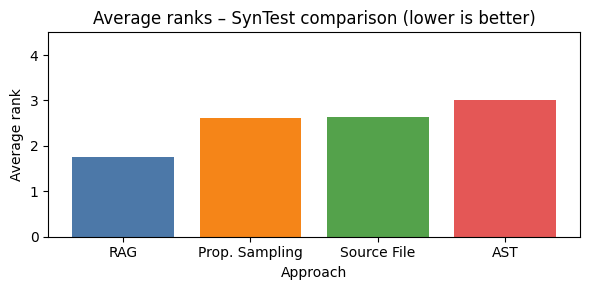

In [16]:
# Average ranks (Demšar-style; rank 1 = best, higher value → lower rank)
ranks_4 = df_4.rank(axis=1, ascending=False)
avg_ranks_4 = ranks_4.mean(axis=0).sort_values()
print("Average ranks (lower is better):")
display(avg_ranks_4.to_frame("avg_rank"))

plt.figure(figsize=(6, 3))
plt.bar(avg_ranks_4.index, avg_ranks_4.values,
        color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title("Average ranks – SynTest comparison (lower is better)")
plt.xlabel("Approach")
plt.ylabel("Average rank")
plt.ylim(0, 4.5)
plt.tight_layout()
plt.show()

Fail to reject null hypothesis that data is normal for column Source File (p=0.153457>=0.012500)
Fail to reject null hypothesis that data is normal for column AST (p=0.119078>=0.012500)
Fail to reject null hypothesis that data is normal for column RAG (p=0.468845>=0.012500)
Fail to reject null hypothesis that data is normal for column Prop. Sampling (p=0.124304>=0.012500)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.308136>=0.050000)
Rejecting null hypothesis that there is no difference between the distributions (p=0.000899)
Using Tukey HSD post hoc test. Differences are significant if the confidence intervals of the mean values are not overlapping.
                meanrank      mean       std ci_lower ci_upper effect_size  \
AST             3.000000  0.150000  0.131059      NaN      NaN         0.0   
Source File     2.638889  0.189444  0.146588      NaN      NaN   -0.283691   
Prop. Sampling  2.6

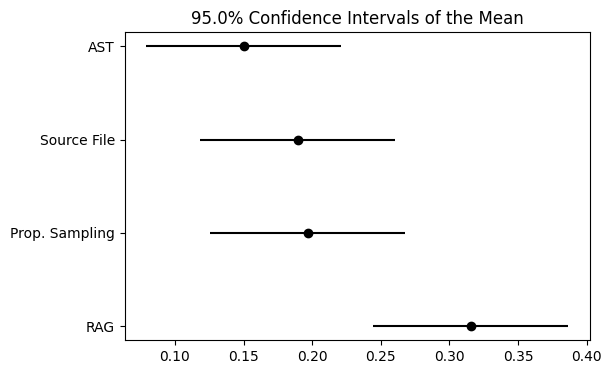

Omnibus test : anova  (p = 0.000899)
Post-hoc test: tukeyhsd

Rank summary (lower rank = better):


,meanrank,mean,std,ci_lower,ci_upper,effect_size,magnitude,effect_size_above,magnitude_above
AST,3.0000,0.1500,0.1311,0.078747,0.221253,0.0,negligible,0.0,negligible
Source File,2.6389,0.1894,0.1466,0.118192,0.260697,-0.283691,small,-0.283691,small
Prop. Sampling,2.6111,0.1967,0.1597,0.125414,0.267919,-0.31949,small,-0.047122,negligible
RAG,1.7500,0.3156,0.2031,0.244303,0.386808,-0.968721,large,-0.650862,medium


In [ ]:
# Error bar plot (4 approaches)
result_4 = autorank(df_4, alpha=0.05, verbose=True, order="descending")

plot_stats(result_4)
plt.show()

# Clean summary
print(f"Omnibus test : {result_4.omnibus}  (p = {result_4.pvalue:.6f})")
print(f"Post-hoc test: {result_4.posthoc}")
print()
print("Rank summary (lower rank = better):")
display(result_4.rankdf.round(4))